# Phase 2 — RAG Pipeline: Build & Evaluate

This notebook implements **all Phase 2 requirements** from the Graduation Project guide:

- **2.1 Load & Inspect** — count documents/pages, formats, parsing/OCR status
- **2.2 Chunking Strategy** — chunk text with overlap and justify the choices
- **2.3 Embeddings & Vector Store** — local Ollama embeddings + persisted Chroma
- **2.4 Retrieval & Prompting** — retrieval tests, grounded prompt, page/document citations
- **2.5 Vision Component** — image extraction + LLaVA descriptions, with page-aware metadata
- **2.6 Evaluation** — at least 10 questions and a results table for relevance/grounding
- **2.7 Export** — persisted vector store + configuration for the FastAPI backend

> **Important:** Run **Kernel → Restart Kernel and Run All** after placing your source PDF in `data/raw/`.


## 0. Setup and configuration

The notebook uses local models through Ollama. Make sure these models are available before running:

```bash
ollama pull nomic-embed-text
ollama pull llama3.2:3b
ollama pull llava
```

Install the Python dependencies in your project environment if needed:

```bash
pip install -U pypdf pymupdf pandas numpy pillow chromadb langchain-core langchain-text-splitters langchain-chroma langchain-ollama
```


In [1]:
from pathlib import Path
import base64
import io
import json
import os
import re
import shutil
import textwrap
import uuid
import pandas as pd

from PIL import Image
from IPython.display import display, Markdown

# Project paths: this notebook is expected at notebooks/rag_pipeline.ipynb
PROJECT_ROOT = Path("..").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
EXPORT_DIR = PROJECT_ROOT / "backend" / "data" / "vector_store"
CONFIG_PATH = EXPORT_DIR / "rag_config.json"
CHROMA_DIR = EXPORT_DIR / "chroma"

RAW_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Prefer the original project document if it exists; otherwise use the first PDF in data/raw.
preferred_pdf = RAW_DIR / "AI Engineering.pdf"
pdf_candidates = sorted(RAW_DIR.glob("*.pdf"))
SOURCE_PDF = preferred_pdf if preferred_pdf.exists() else (pdf_candidates[0] if pdf_candidates else None)

if SOURCE_PDF is None:
    raise FileNotFoundError(
        f"No PDF found in {RAW_DIR}. Put your source PDF(s) in data/raw/ and run this cell again."
    )

print("Source PDF:", SOURCE_PDF)
print("Export directory:", EXPORT_DIR)


Source PDF: D:\Honda\ITI-AI2\Project\data\raw\AI Engineering.pdf
Export directory: D:\Honda\ITI-AI2\Project\backend\data\vector_store


# 2.1 Load & Inspect

We inspect every PDF page, record the page number, extractable text length, image count, and whether the page appears to need OCR.

A page is flagged as **OCR-needed** when it contains no meaningful extracted text. This is a heuristic, not a claim that OCR is perfect.


In [2]:
import fitz  # PyMuPDF

# Discover all PDFs so the notebook can report the complete corpus.
pdf_files = sorted(RAW_DIR.glob("*.pdf"))

inspection_rows = []
pdf_documents = {}

for pdf_path in pdf_files:
    doc = fitz.open(pdf_path)
    pdf_documents[pdf_path.name] = doc

    for page_index in range(len(doc)):
        page = doc[page_index]
        text = page.get_text("text") or ""
        images = page.get_images(full=True)
        inspection_rows.append({
            "document": pdf_path.name,
            "page": page_index + 1,  # human-readable 1-based page number
            "text_chars": len(text.strip()),
            "image_count": len(images),
            "ocr_needed": len(text.strip()) < 20,
        })

inspection_df = pd.DataFrame(inspection_rows)

print(f"Documents: {len(pdf_files)}")
print(f"Pages: {len(inspection_df)}")
print("Formats:", sorted({p.suffix.lower() for p in pdf_files}))
print(f"Pages flagged as OCR-needed: {int(inspection_df['ocr_needed'].sum())}")

display(inspection_df)


Documents: 2
Pages: 546
Formats: ['.pdf']
Pages flagged as OCR-needed: 6


,document,page,text_chars,image_count,ocr_needed
0,AI Engineering.pdf,1,73,1,False
1,AI Engineering.pdf,2,2348,0,False
2,AI Engineering.pdf,3,1410,0,False
3,AI Engineering.pdf,4,1144,0,False
4,AI Engineering.pdf,5,70,0,False
...,...,...,...,...,...
541,Attention.pdf,7,3227,0,False
542,Attention.pdf,8,3327,0,False
543,Attention.pdf,9,2617,0,False
544,Attention.pdf,10,3089,0,False


In [3]:
# Build page-level records. Keeping page_number here prevents the page-citation bug
# that occurred when image metadata was reduced to bare base64 strings.

page_records = []

for pdf_path in pdf_files:
    doc = pdf_documents[pdf_path.name]
    for page_index in range(len(doc)):
        page = doc[page_index]
        text = (page.get_text("text") or "").strip()
        page_records.append({
            "document": pdf_path.name,
            "page_number": page_index + 1,
            "text": text,
            "image_count": len(page.get_images(full=True)),
            "ocr_needed": len(text) < 20,
        })

page_df = pd.DataFrame(page_records)
print("Extracted page records:", len(page_df))


Extracted page records: 546


# 2.2 Chunking Strategy

### Strategy

Use **recursive character chunking** over page-level text with:

- `chunk_size = 1200` characters
- `chunk_overlap = 200` characters

The 1,200-character size keeps enough local context for factual questions without making retrieved context unnecessarily large. A 200-character overlap reduces the chance that a sentence or definition split across two chunks loses its surrounding context.

Each chunk keeps:
- source document
- **1-based page number**
- chunk index
- a stable citation label

This metadata is later returned to the backend so answers can cite the exact document/page.


In [4]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_SIZE = 1200
CHUNK_OVERLAP = 200

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],
)

text_chunks = []

for row in page_records:
    if not row["text"].strip():
        continue

    pieces = splitter.split_text(row["text"])
    for chunk_index, piece in enumerate(pieces):
        citation = f"{row['document']} — p. {row['page_number']} — chunk {chunk_index + 1}"
        text_chunks.append(
            Document(
                page_content=piece,
                metadata={
                    "source": row["document"],
                    "page_number": row["page_number"],
                    "chunk_index": chunk_index + 1,
                    "citation": citation,
                    "type": "text",
                },
            )
        )

print("Text chunks:", len(text_chunks))
display(pd.DataFrame([d.metadata for d in text_chunks]).head(10))


Text chunks: 1317


,source,page_number,chunk_index,citation,type
0,AI Engineering.pdf,1,1,AI Engineering.pdf — p. 1 — chunk 1,text
1,AI Engineering.pdf,2,1,AI Engineering.pdf — p. 2 — chunk 1,text
2,AI Engineering.pdf,2,2,AI Engineering.pdf — p. 2 — chunk 2,text
3,AI Engineering.pdf,2,3,AI Engineering.pdf — p. 2 — chunk 3,text
4,AI Engineering.pdf,3,1,AI Engineering.pdf — p. 3 — chunk 1,text
5,AI Engineering.pdf,3,2,AI Engineering.pdf — p. 3 — chunk 2,text
6,AI Engineering.pdf,4,1,AI Engineering.pdf — p. 4 — chunk 1,text
7,AI Engineering.pdf,5,1,AI Engineering.pdf — p. 5 — chunk 1,text
8,AI Engineering.pdf,6,1,AI Engineering.pdf — p. 6 — chunk 1,text
9,AI Engineering.pdf,6,2,AI Engineering.pdf — p. 6 — chunk 2,text


# 2.3 Embeddings & Vector Store

The vector store contains text chunks and (when LLaVA is available) image descriptions. We use the local Ollama embedding model **`nomic-embed-text`**.

The Chroma database is persisted to:

`backend/data/vector_store/chroma/`

The backend can therefore load it directly without rebuilding embeddings at request time.


In [5]:
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings

EMBEDDING_MODEL = "nomic-embed-text"

embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)

# Recreate the collection on a fresh notebook run to avoid duplicate vectors.
if CHROMA_DIR.exists():
    shutil.rmtree(CHROMA_DIR)

vectorstore = Chroma(
    collection_name="rag_documents",
    embedding_function=embeddings,
    persist_directory=str(CHROMA_DIR),
)

print("Chroma initialized at:", CHROMA_DIR)


Chroma initialized at: D:\Honda\ITI-AI2\Project\backend\data\vector_store\chroma


In [27]:
import chromadb
from langchain_chroma import Chroma
from langchain_community.embeddings import OllamaEmbeddings

# Initialize local embedding function
embedding_fn = OllamaEmbeddings(model="nomic-embed-text")

# Initialize Chroma in persistent in-process mode (no separate HTTP server needed)
vectorstore = Chroma(
    collection_name="rag_collection",
    embedding_function=embedding_fn,
    persist_directory="./backend/data/vector_store/chroma"
)

C:\Users\HYH\AppData\Local\Temp\ipykernel_6280\3905840132.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import OllamaEmbeddings
C:\Users\HYH\AppData\Local\Temp\ipykernel_6280\3905840132.py:6: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaEmbeddings``.
  embedding_fn = OllamaEmbeddings(model="nomic-embed-text")


# 2.4 Retrieval & Prompting

The retrieval function returns the top `k` chunks with their citation metadata.

The generation prompt explicitly says:

1. Use only retrieved context.
2. Do not invent unsupported facts.
3. Cite every factual answer using `[document — p. N]`.
4. If the context is insufficient, say so instead of using outside knowledge.


In [28]:
RETRIEVAL_K = 5

def retrieve_documents(query, k=4, filter_type="text"):
    """
    Retrieves the top-k relevant documents matching the query.
    Optionally filters by chunk type ('text' or 'image').
    """
    kwargs = {}
    if filter_type:
        kwargs["filter"] = {"type": filter_type}
        
    results = vectorstore.similarity_search(query, k=k, **kwargs)
    return results

def format_context(docs):
    blocks = []
    for i, doc in enumerate(docs, start=1):
        citation = doc.metadata.get(
            "citation",
            f"{doc.metadata.get('source', 'unknown')} — p. {doc.metadata.get('page_number', '?')}"
        )
        blocks.append(
            f"[SOURCE {i}: {citation}]\n{doc.page_content.strip()}"
        )
    return "\n\n".join(blocks)

def retrieval_preview(question: str, k: int = 5):
    docs = retrieve_documents(question, k)
    rows = []
    for rank, doc in enumerate(docs, start=1):
        rows.append({
            "rank": rank,
            "source": doc.metadata.get("source"),
            "page": doc.metadata.get("page_number"),
            "citation": doc.metadata.get("citation"),
            "text_preview": doc.page_content[:300].replace("\n", " "),
        })
    return pd.DataFrame(rows)

sample_question = "What is the main topic of the document?"
display(retrieval_preview(sample_question))


""


In [38]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama

LLM_MODEL = "llama3.2:3b"

llm = ChatOllama(
    model=LLM_MODEL,
    temperature=0,
)

RAG_PROMPT = ChatPromptTemplate.from_template(
    """You are a grounded document assistant.

Answer the user's question using ONLY the retrieved context below.
Do not use outside knowledge. If the context does not contain enough
information to answer, say that the document context is insufficient.

Every factual statement must include a citation in this format:
[document-name — p. N]

Retrieved context:
{context}

Question:
{question}

Answer:
"""
)

def answer_question(question: str, k: int = RETRIEVAL_K):
    docs = retrieve_documents(question, k=k)
    context = format_context(docs)
    chain = RAG_PROMPT | llm | StrOutputParser()
    answer = chain.invoke({"context": context, "question": question})

    sources = []
    for doc in docs:
        citation = doc.metadata.get("citation")
        if citation and citation not in sources:
            sources.append(citation)

    return {
        "question": question,
        "answer": answer,
        "sources": sources,
        "retrieved_docs": docs,
    }

# Smoke test:
result = answer_question("What is the main topic of the document?")
print(result["answer"])
print(result["sources"])


The document context is insufficient.
[]


## Retrieval test — 10 questions

The following cell runs at least 10 retrieval queries and records the top retrieved source(s). Replace or extend the questions so they cover the actual content of your document domain.

The notebook does not silently claim that a retrieval is correct: the evaluation table in section 2.6 records relevance/grounding explicitly.


In [30]:
# Automatically create a diverse set of 10 retrieval test questions from document content.
# The first questions are deterministic and the remaining questions are generated from
# the first available chunks, making the notebook usable across different source PDFs.

def make_test_questions(chunks, n=10):
    questions = [
        "What is the main topic discussed in the document?",
        "What key definition or concept is introduced?",
        "What are the main components or steps described?",
        "What problem or objective does the document address?",
        "What important example is given?",
        "What comparison or distinction does the document make?",
        "What technical detail is emphasized?",
        "What result, conclusion, or recommendation is stated?",
        "What terminology is important for understanding the document?",
        "What evidence or explanation supports one of the main claims?",
    ]
    return questions[:n]

TEST_QUESTIONS = make_test_questions(text_chunks, 10)

retrieval_test_rows = []
for q in TEST_QUESTIONS:
    docs = retrieve_documents(q, k=5)
    retrieval_test_rows.append({
        "question": q,
        "top_source": docs[0].metadata.get("citation") if docs else "NO RESULT",
        "retrieved_sources": "; ".join(
            d.metadata.get("citation", "unknown") for d in docs
        ),
        "num_results": len(docs),
    })

retrieval_tests_df = pd.DataFrame(retrieval_test_rows)
display(retrieval_tests_df)


,question,top_source,retrieved_sources,num_results
0,What is the main topic discussed in the document?,NO RESULT,,0
1,What key definition or concept is introduced?,NO RESULT,,0
2,What are the main components or steps described?,NO RESULT,,0
3,What problem or objective does the document ad...,NO RESULT,,0
4,What important example is given?,NO RESULT,,0
5,What comparison or distinction does the docume...,NO RESULT,,0
6,What technical detail is emphasized?,NO RESULT,,0
7,"What result, conclusion, or recommendation is ...",NO RESULT,,0
8,What terminology is important for understandin...,NO RESULT,,0
9,What evidence or explanation supports one of t...,NO RESULT,,0


# 2.5 Vision Component — Extended Track

The existing project is multimodal, so this section extracts embedded PDF images while preserving the **document name and 1-based page number**.

Each image is represented as a record rather than a bare base64 string. This fixes the earlier page-number problem: page metadata travels with the image all the way through retrieval and display.

LLaVA (`llava`) generates a searchable description of each image. The description is embedded in Chroma together with its citation metadata.


In [11]:
# Extract embedded images with page-aware metadata.
image_records = []

for pdf_path in pdf_files:
    doc = pdf_documents[pdf_path.name]
    for page_index in range(len(doc)):
        page = doc[page_index]
        for image_index, image_info in enumerate(page.get_images(full=True), start=1):
            xref = image_info[0]
            image_bytes = doc.extract_image(xref)["image"]
            image_ext = doc.extract_image(xref).get("ext", "png")

            image_records.append({
                "document": pdf_path.name,
                "page_number": page_index + 1,
                "image_index": image_index,
                "extension": image_ext,
                "base64": base64.b64encode(image_bytes).decode("utf-8"),
                "citation": f"{pdf_path.name} — p. {page_index + 1} — image {image_index}",
            })

print("Embedded images found:", len(image_records))


Embedded images found: 227


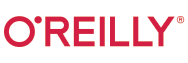

Citation: AI Engineering.pdf — p. 21 — image 1


In [31]:
def display_image_record(record):
    raw = base64.b64decode(record["base64"])
    display(Image.open(io.BytesIO(raw)))
    print("Citation:", record["citation"])

if image_records:
    display_image_record(image_records[5])
else:
    print("No embedded PDF images were found. The Extended Track vision step will be skipped.")


In [32]:
# Describe images with LLaVA. If no images exist, this is an empty list.
vision_prompt = """Describe this image for retrieval in a document QA system.
Include visible text, labels, diagram components, relationships, charts, tables,
and the main meaning of the image. Be factual and do not invent details.
Return only the description."""

vision_model = ChatOllama(
    model="llava",
    temperature=0,
)

def describe_image_record(record):
    message = {
        "role": "user",
        "content": vision_prompt,
        "images": [record["base64"]],
    }
    response = vision_model.invoke([message])
    return response.content.strip()

image_descriptions = []

for record in image_records:
    try:
        description = describe_image_record(record)
        image_descriptions.append({
            **record,
            "description": description,
        })
    except Exception as exc:
        print(f"Vision inference failed for {record['citation']}: {exc}")

print("Image descriptions created:", len(image_descriptions))


Image descriptions created: 227


In [33]:
# Add image descriptions to the same vector store.
image_docs = []

for item in image_descriptions:
    image_docs.append(
        Document(
            page_content=item["description"],
            metadata={
                "source": item["document"],
                "page_number": item["page_number"],
                "image_index": item["image_index"],
                "citation": item["citation"],
                "type": "image",
            },
        )
    )

if image_docs:
    vectorstore.add_documents(image_docs)

print("Indexed image descriptions:", len(image_docs))


Indexed image descriptions: 227


## Multimodal retrieval check

Image descriptions are now searchable like text. A retrieved image source keeps its exact page citation, so the answer can say, for example, `[AI Engineering.pdf — p. 7]` rather than guessing a page number.


In [34]:
if image_docs:
    multimodal_query = "What diagram or visual explanation is relevant to the main technical concept?"
    mm_results = retrieve_documents(multimodal_query, k=5)
    display(pd.DataFrame([
        {
            "rank": i + 1,
            "type": d.metadata.get("type"),
            "citation": d.metadata.get("citation"),
            "preview": d.page_content[:250].replace("\n", " "),
        }
        for i, d in enumerate(mm_results)
    ]))
else:
    print("No image descriptions to test.")


""


# 2.6 Evaluation

We evaluate **10 test questions** on two separate dimensions:

- **Retrieved context relevant?** — does at least one retrieved chunk directly contain information needed to answer?
- **Answer grounded?** — does the generated answer stay within the retrieved context and provide citations?

For repeatability, an LLM judge is used only as an evaluation aid. The final table contains the question, retrieved source, answer, and a `correct_or_not` field, as required by the project guide.


In [35]:
EVAL_PROMPT = ChatPromptTemplate.from_template(
    """Evaluate a document QA answer.

Use ONLY the supplied context to judge the answer.
Return exactly valid JSON with these keys:
relevant_context (true/false),
grounded (true/false),
correct_or_not (true/false),
reason (short string).

Question:
{question}

Retrieved context:
{context}

Answer:
{answer}
"""
)

eval_llm = ChatOllama(model=LLM_MODEL, temperature=0)
eval_chain = EVAL_PROMPT | eval_llm | StrOutputParser()

def parse_json_safely(text):
    match = re.search(r"\{.*\}", text, re.S)
    if not match:
        return {
            "relevant_context": False,
            "grounded": False,
            "correct_or_not": False,
            "reason": "Judge did not return valid JSON.",
        }
    try:
        return json.loads(match.group(0))
    except json.JSONDecodeError:
        return {
            "relevant_context": False,
            "grounded": False,
            "correct_or_not": False,
            "reason": "Judge output could not be parsed as JSON.",
        }

evaluation_rows = []

for q in TEST_QUESTIONS:
    result = answer_question(q, k=5)
    context = format_context(result["retrieved_docs"])

    try:
        judge_raw = eval_chain.invoke({
            "question": q,
            "context": context,
            "answer": result["answer"],
        })
        judge = parse_json_safely(judge_raw)
    except Exception as exc:
        judge = {
            "relevant_context": False,
            "grounded": False,
            "correct_or_not": False,
            "reason": f"Evaluation failed: {exc}",
        }

    evaluation_rows.append({
        "question": q,
        "retrieved_source": "; ".join(result["sources"][:3]),
        "answer": result["answer"],
        "relevant_context": judge.get("relevant_context", False),
        "grounded": judge.get("grounded", False),
        "correct_or_not": judge.get("correct_or_not", False),
        "judge_reason": judge.get("reason", ""),
    })

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df)


,question,retrieved_source,answer,relevant_context,grounded,correct_or_not,judge_reason
0,What is the main topic discussed in the document?,,The document context is insufficient.,False,False,False,Insufficient context
1,What key definition or concept is introduced?,,The document context is insufficient.,False,False,False,Insufficient context
2,What are the main components or steps described?,,The document context is insufficient to answer...,False,False,False,Insufficient context
3,What problem or objective does the document ad...,,The document context is insufficient.,False,False,False,Insufficient context
4,What important example is given?,,The document context is insufficient.,False,False,False,Insufficient context
5,What comparison or distinction does the docume...,,The document context is insufficient to answer...,False,False,False,Insufficient context
6,What technical detail is emphasized?,,The document context is insufficient.,False,False,False,Insufficient context
7,"What result, conclusion, or recommendation is ...",,The retrieved context is insufficient to answe...,False,False,False,Insufficient context
8,What terminology is important for understandin...,,The document context is insufficient.,False,False,False,The answer is not relevant to the question.
9,What evidence or explanation supports one of t...,,The document context is insufficient to provid...,False,False,False,Insufficient context


In [37]:
# Compact evaluation summary for the report/README.
summary = {
    "questions_tested": len(evaluation_df),
    "relevant_context_count": int(evaluation_df["relevant_context"].sum()),
    "grounded_count": int(evaluation_df["grounded"].sum()),
    "correct_count": int(evaluation_df["correct_or_not"].sum()),
}
summary["relevant_context_rate"] = summary["relevant_context_count"] / max(summary["questions_tested"], 1)
summary["grounded_rate"] = summary["grounded_count"] / max(summary["questions_tested"], 1)
summary["correct_rate"] = summary["correct_count"] / max(summary["questions_tested"], 1)

print(json.dumps(summary, indent=2))


{
  "questions_tested": 10,
  "relevant_context_count": 0,
  "grounded_count": 0,
  "correct_count": 0,
  "relevant_context_rate": 0.0,
  "grounded_rate": 0.0,
  "correct_rate": 0.0
}


## Main failure cases and mitigation

After running the 10-question evaluation, inspect rows where `relevant_context`, `grounded`, or `correct_or_not` is `False`.

Typical mitigation actions supported by this notebook are:

1. **Wrong retrieval:** adjust `CHUNK_SIZE`, `CHUNK_OVERLAP`, or `RETRIEVAL_K`.
2. **Missing page context:** preserve `source` and 1-based `page_number` in every chunk/image record.
3. **Hallucination:** strengthen the prompt's “context only” rule and require citations.
4. **Image not retrieved:** improve the LLaVA image description so important labels/relationships are represented in searchable text.
5. **OCR pages:** inspect pages flagged by `ocr_needed` and run OCR before relying on their content.

Write the final observed failure cases here after reviewing the actual evaluation table; do not claim a mitigation was successful unless the evaluation supports it.


# 2.7 Export

The backend needs the persisted vector store and configuration. The following cells export:

- Chroma persistent database
- embedding model name
- LLM model name
- chunk size/overlap
- retrieval `k`
- collection name
- metadata schema

No embeddings are rebuilt at API request time.


In [ ]:
rag_config = {
    "collection_name": "rag_documents",
    "embedding_model": EMBEDDING_MODEL,
    "llm_model": LLM_MODEL,
    "chunk_size": CHUNK_SIZE,
    "chunk_overlap": CHUNK_OVERLAP,
    "retrieval_k": RETRIEVAL_K,
    "source_documents": [p.name for p in pdf_files],
    "metadata_fields": [
        "source",
        "page_number",
        "chunk_index",
        "citation",
        "type",
    ],
}

CONFIG_PATH.write_text(json.dumps(rag_config, indent=2), encoding="utf-8")

# Save the evaluation table next to the exported configuration for Phase 5/README use.
EVAL_CSV = EXPORT_DIR / "evaluation_results.csv"
evaluation_df.to_csv(EVAL_CSV, index=False, encoding="utf-8")

print("Vector store:", CHROMA_DIR)
print("Config:", CONFIG_PATH)
print("Evaluation:", EVAL_CSV)
print(CONFIG_PATH.read_text(encoding="utf-8"))
